In [140]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime
import pandas as pd
from glob import glob

In [141]:
# import zipfile

# #** unzip the folder GLEM_daily_dataset.zip **
# with zipfile.ZipFile("GLEM_daily_dataset.zip", "r") as zip_ref:
#     zip_ref.extractall("GLEM_daily_dataset")

# #** unzip the folder MADIA_daily_dataset_v1.3.zip **
# with zipfile.ZipFile("MADIA_daily_dataset_v1.3.zip", "r") as zip_ref:
#     zip_ref.extractall("MADIA_daily_dataset_v1.3")

In [142]:
#** load the dataframe of climatological variables **

# load data from the csv files
csv_files = sorted(glob("./Datasets/MADIA_daily_dataset_v1.3/csv_data/*_e5_d.csv"))
csv_files = [file for file in csv_files if 2018 <= int(file.split('/')[-1].split('_')[0]) <= 2022]

dailyClimatological_data = pd.DataFrame()
veneto_dailyClimatological_data = pd.DataFrame()

for file in csv_files:
    df = pd.read_csv(file)

    # keep only the data that are referred to the Piedmont region
    df_piedmont = df[df['latitude'].between(44.0, 46.5) & df['longitude'].between(6.5, 9.0)]
    df_veneto = df[df['latitude'].between(45.0, 46.5) & df['longitude'].between(11.0, 13.0)]
    
    global_dailyClimatological_data = pd.concat([dailyClimatological_data, df], ignore_index=True)
    dailyClimatological_data = pd.concat([dailyClimatological_data, df_piedmont], ignore_index=True)

print(dailyClimatological_data.head())

# tasmin    mean of daily minimum near-surface air temperature
# tasmean   mean of daily average near-surface air temperature
# tasmax    mean of daily maximum near-surface air temperature
# rhmin     mean of daily minimum near-surface relative air humidity
# rhmax     mean of daily maximum near-surface relative air humidity
# ws10      mean of daily wind speed
# ssrd      mean of daily surface solar radiation downwards (shortwave radiation)
# ppn       sum of daily depth of water-equivalent precipitation
# pev       sum of daily crop reference evapotranspiration estimated by FAO Penman-Monteith method
# zg        geopotential height: average cell height (metres) above the geoid, which corresponds approximately to the elevation
# dekad     number of dekad from the beginning of the year
# expver    code which identiﬁes temporary data when expver=5
# mask      boolean code to identify cells belonging to the Italian country

   longitude  latitude        time    tasmin     tasmax   tasmean     rhmin  \
0       7.25      44.0  2018-01-01  0.558990   7.124176  3.841583  0.451363   
1       7.25      44.0  2018-01-02 -0.167053   8.914368  4.373657  0.251159   
2       7.25      44.0  2018-01-03 -0.717499  10.041382  4.661942  0.476920   
3       7.25      44.0  2018-01-04  1.295715  11.309570  6.302643  0.607979   
4       7.25      44.0  2018-01-05  1.708557  10.772156  6.240356  0.637630   

      rhmax      ws10      ssrd       ppn       pev  expver  mask  
0  0.885065  1.842568  7.441170  0.859861  0.614040     1.0   1.0  
1  0.710465  2.117030  6.604702  0.010734  1.068140     1.0   1.0  
2  0.766035  2.381270  5.937560  0.550878  0.968159     1.0   1.0  
3  0.843676  1.732611  6.783000  1.500057  0.636623     1.0   1.0  
4  0.965799  1.507447  6.272125  0.325084  0.528646     1.0   1.0  


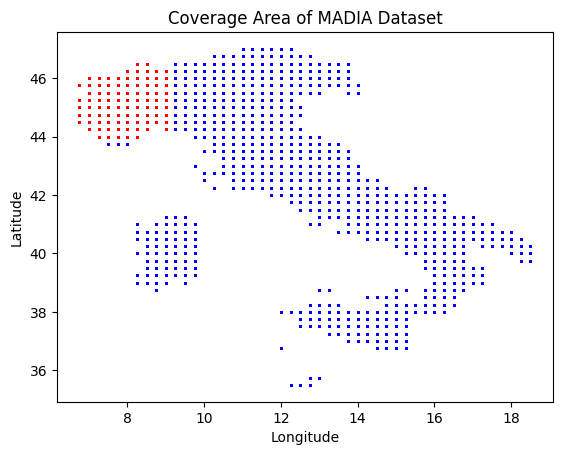

In [143]:
# **show a plot of the coverage area of the MADIA dataset **

# color in red the area of the Piedmont region
plt.scatter(global_dailyClimatological_data['longitude'], global_dailyClimatological_data['latitude'], s=1, c='blue', alpha=0.5)
plt.scatter(dailyClimatological_data['longitude'], dailyClimatological_data['latitude'], s=1, c='red', alpha=0.5)
plt.title('Coverage Area of MADIA Dataset')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [144]:
#** load the dataset of Evapotranspiration from the nc file **

nc_files = sorted(glob("./Datasets/GLEM_daily_dataset/E_*_GLEAM_v4.2a.nc"))
nc_files = [file for file in nc_files if 2018 <= int(file.split('/')[-1].split('_')[1]) <= 2022]

dailyE_data = []

for file in nc_files:
    ds = xr.open_dataset(file)

    # the evapotranspiration data are referenced to the Global territory
    E_lon = ds['lon'].values
    E_lat = ds['lat'].values

    # the climatological data are referenced to the Italian territory
    clim_lon = dailyClimatological_data['longitude'].values
    clim_lat = dailyClimatological_data['latitude'].values

    # select the evapotranspiration data for the Italian territory
    E_lon_idx = np.where((E_lon >= clim_lon.min()) & (E_lon <= clim_lon.max()))
    E_lat_idx = np.where((E_lat >= clim_lat.min()) & (E_lat <= clim_lat.max()))
    E_piedmont_lon = E_lon[E_lon_idx]
    E_piedmont_lat = E_lat[E_lat_idx]

    E_data = ds['E'].sel(lon=E_piedmont_lon, lat=E_piedmont_lat)
    dailyE_data.append(E_data)

dailyE_data = xr.concat(dailyE_data, dim='time')

/tmp/ipykernel_7965/1734681239.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis').copy()    # create a copy of the colormap


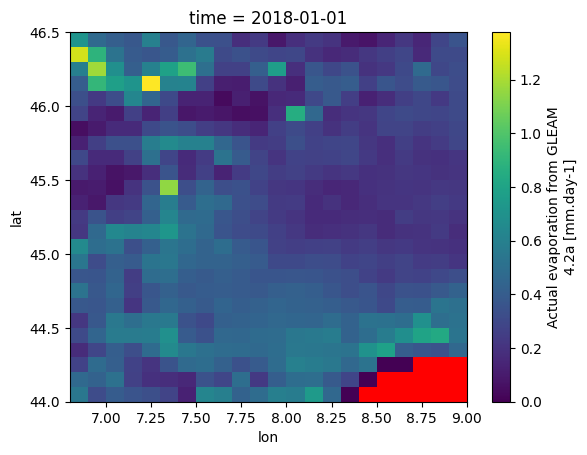

Daily Evapotranspiration shape (time, latitude, longitude): (1826, 25, 22)
Number of NaN values in the dataset: 14


In [145]:
#** show a plot of the Evapotranspiration data **

et = dailyE_data.isel(time=0)

cmap = cm.get_cmap('viridis').copy()    # create a copy of the colormap
cmap.set_bad(color='red')  # highlight NaN values in red

et.plot(cmap=cmap)  # plot the data with the modified colormap

plt.show()

print(f"Daily Evapotranspiration shape (time, latitude, longitude): {dailyE_data.shape}")

# count the number of pixel that are NaN at any time
nan_pixels = np.isnan(dailyE_data).any(dim='time').sum().item()
print(f"Number of NaN values in the dataset: {nan_pixels}")

In [146]:
#** evaluate the elapsed_days **

dailyClimatological_data['time'] = pd.to_datetime(dailyClimatological_data['time'])
dailyClimatological_data['elapsed_days'] = (dailyClimatological_data['time'] - dailyClimatological_data['time'].min()).dt.days.values
dailyClimatological_data['day_of_year'] = dailyClimatological_data['time'].dt.dayofyear.values

print("Piedmont Daily Climatological Data:")
print(dailyClimatological_data.head())
print(dailyClimatological_data.tail())

Piedmont Daily Climatological Data:
   longitude  latitude       time    tasmin     tasmax   tasmean     rhmin  \
0       7.25      44.0 2018-01-01  0.558990   7.124176  3.841583  0.451363   
1       7.25      44.0 2018-01-02 -0.167053   8.914368  4.373657  0.251159   
2       7.25      44.0 2018-01-03 -0.717499  10.041382  4.661942  0.476920   
3       7.25      44.0 2018-01-04  1.295715  11.309570  6.302643  0.607979   
4       7.25      44.0 2018-01-05  1.708557  10.772156  6.240356  0.637630   

      rhmax      ws10      ssrd       ppn       pev  expver  mask  \
0  0.885065  1.842568  7.441170  0.859861  0.614040     1.0   1.0   
1  0.710465  2.117030  6.604702  0.010734  1.068140     1.0   1.0   
2  0.766035  2.381270  5.937560  0.550878  0.968159     1.0   1.0   
3  0.843676  1.732611  6.783000  1.500057  0.636623     1.0   1.0   
4  0.965799  1.507447  6.272125  0.325084  0.528646     1.0   1.0   

   elapsed_days  day_of_year  
0             0            1  
1             1   

In [147]:
#** associate the Evapotranspiration data to the climatological data **

# build a 2D grid of lat/lon points with the evapotranspiration data
grid_lat = dailyE_data['lat'].values
grid_lon = dailyE_data['lon'].values
grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

from scipy.spatial import cKDTree

# build a KDTree for fast nearest-neighbor search
grid_points = np.column_stack([grid_lat2d.ravel(), grid_lon2d.ravel()])
tree = cKDTree(grid_points)

# extract (lat, lon) from the climate data
query_points = dailyClimatological_data[['latitude', 'longitude']].values

# query the nearest grid points once
distances, indices = tree.query(query_points)

# convert flat indices to 2D (lat_idx, lon_idx)
lat_idx, lon_idx = np.unravel_index(indices, grid_lat2d.shape)

# time indices, evaluate the amount of days elapsed since the first day of the dataset
time_idx = dailyClimatological_data['elapsed_days']

# get values from xarray using vectorized indexing
E_values = dailyE_data.isel(
    time=xr.DataArray(time_idx, dims='points'),
    lat=xr.DataArray(lat_idx, dims='points'),
    lon=xr.DataArray(lon_idx, dims='points')
).values

# Assign to DataFrame
dailyClimatological_data['E'] = E_values

print(dailyClimatological_data.head())
print(dailyClimatological_data.tail())
print(f"Correction (degrees) - mean: {np.mean(distances):.6f}, min: {np.min(distances):.6f}, max: {np.max(distances):.6f}")

   longitude  latitude       time    tasmin     tasmax   tasmean     rhmin  \
0       7.25      44.0 2018-01-01  0.558990   7.124176  3.841583  0.451363   
1       7.25      44.0 2018-01-02 -0.167053   8.914368  4.373657  0.251159   
2       7.25      44.0 2018-01-03 -0.717499  10.041382  4.661942  0.476920   
3       7.25      44.0 2018-01-04  1.295715  11.309570  6.302643  0.607979   
4       7.25      44.0 2018-01-05  1.708557  10.772156  6.240356  0.637630   

      rhmax      ws10      ssrd       ppn       pev  expver  mask  \
0  0.885065  1.842568  7.441170  0.859861  0.614040     1.0   1.0   
1  0.710465  2.117030  6.604702  0.010734  1.068140     1.0   1.0   
2  0.766035  2.381270  5.937560  0.550878  0.968159     1.0   1.0   
3  0.843676  1.732611  6.783000  1.500057  0.636623     1.0   1.0   
4  0.965799  1.507447  6.272125  0.325084  0.528646     1.0   1.0   

   elapsed_days  day_of_year         E  
0             0            1  0.331563  
1             1            2  0.56

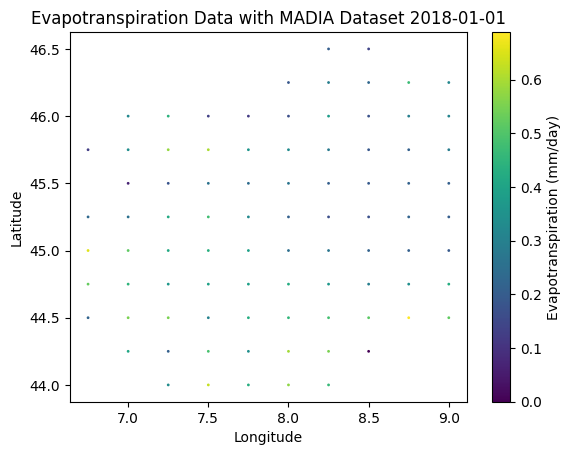

In [148]:
#** show a plot of the Evapotranspiration data with the MADIA dataset **

et = dailyClimatological_data[dailyClimatological_data['elapsed_days'] == 0]
plt.scatter(et['longitude'], et['latitude'], s=1, c=et['E'], cmap='viridis')
plt.colorbar(label='Evapotranspiration (mm/day)')
plt.title(f'Evapotranspiration Data with MADIA Dataset {et["time"].dt.strftime("%Y-%m-%d").values[0]}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [149]:
#** drop the rows with NaN values in the Evapotranspiration column **

print(f"Number of rows before dropping NaN values: {len(dailyClimatological_data)}")
dailyClimatological_data = dailyClimatological_data.dropna(subset=['E'])
print(f"Number of rows after dropping NaN values: {len(dailyClimatological_data)}")

Number of rows before dropping NaN values: 160688
Number of rows after dropping NaN values: 158862


In [150]:
#** print the fields of the dataframe **
print(dailyClimatological_data.columns)

Index(['longitude', 'latitude', 'time', 'tasmin', 'tasmax', 'tasmean', 'rhmin',
       'rhmax', 'ws10', 'ssrd', 'ppn', 'pev', 'expver', 'mask', 'elapsed_days',
       'day_of_year', 'E'],
      dtype='object')


In [151]:
#** apply normalization to the features **

from sklearn.preprocessing import StandardScaler

# normilize the features
features = ['day_of_year', 'tasmin', 'tasmean', 'tasmax', 'rhmin', 'rhmax', 'ws10', 'ssrd', 'ppn']
featureScaler = StandardScaler()
dailyClimatological_data[features] = featureScaler.fit_transform(dailyClimatological_data[features])

# normilize the target
target = 'E'
targetScaler = StandardScaler()
dailyClimatological_data[target] = targetScaler.fit_transform(dailyClimatological_data[[target]])

print(dailyClimatological_data.head())

   longitude  latitude       time    tasmin    tasmax   tasmean     rhmin  \
0       7.25      44.0 2018-01-01 -0.549944 -0.668331 -0.620670 -0.612364   
1       7.25      44.0 2018-01-02 -0.630830 -0.482062 -0.562526 -1.729659   
2       7.25      44.0 2018-01-03 -0.692153 -0.364796 -0.531024 -0.469738   
3       7.25      44.0 2018-01-04 -0.467869 -0.232841 -0.351732  0.261675   
4       7.25      44.0 2018-01-05 -0.421875 -0.288759 -0.358539  0.427146   

      rhmax      ws10      ssrd       ppn       pev  expver  mask  \
0  0.017546  0.455215 -0.898778 -0.347942  0.614040     1.0   1.0   
1 -1.653248  0.799291 -1.008861 -0.450176  1.068140     1.0   1.0   
2 -1.121484  1.130552 -1.096660 -0.385143  0.968159     1.0   1.0   
3 -0.378517  0.317370 -0.985396 -0.270863  0.636623     1.0   1.0   
4  0.790122  0.035095 -1.052629 -0.412329  0.528646     1.0   1.0   

   elapsed_days  day_of_year         E  
0             0    -1.727310 -0.893383  
1             1    -1.717825 -0.681489  

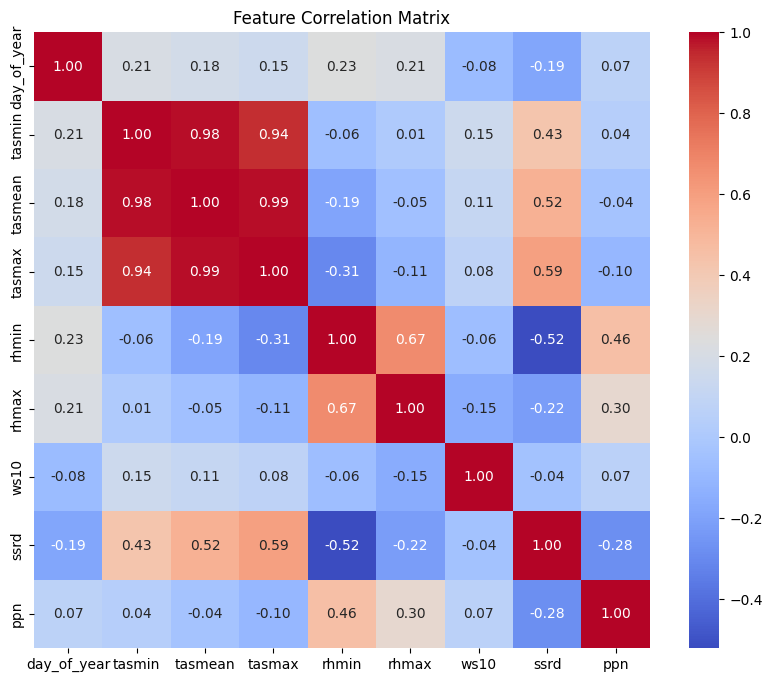

In [152]:
#** analyze the correlation between the features in the dataset **

import seaborn as sns

correlation_matrix = dailyClimatological_data[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

**Remove Features**

In [153]:
#** alternatively to PCA, remove from the dataset the features that are highly correlated **

threshold = 0.6
to_drop = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            to_drop.add(colname)
print(f"Features to drop due to high correlation: {to_drop}")
reduced_dataset = dailyClimatological_data.drop(columns=to_drop)
print(f"Remaining features after dropping highly correlated ones: {reduced_dataset.columns}")

Features to drop due to high correlation: {'tasmax', 'tasmean', 'rhmax'}
Remaining features after dropping highly correlated ones: Index(['longitude', 'latitude', 'time', 'tasmin', 'rhmin', 'ws10', 'ssrd',
       'ppn', 'pev', 'expver', 'mask', 'elapsed_days', 'day_of_year', 'E'],
      dtype='object')


In [154]:
# save the processed data to a CSV file
reduced_dataset.to_csv('./ProcessedDatasets/processed_climatological_data.csv', index=False)

In [155]:
# reduced dataset but without precipitation

reduced_dataset_no_ppn = reduced_dataset.drop(columns=['ppn'])
reduced_dataset_no_ppn.to_csv('./ProcessedDatasets/processed_climatological_data_no_ppn.csv', index=False)

**Random mising input features**

In [156]:
# randomly set individual feature values (not entire rows) to NaN
missingValues_dataset = dailyClimatological_data.copy()
num_points = int(missingValues_dataset[features].size * 0.1)  # 10% of all feature values
row_indices = np.random.choice(missingValues_dataset.index, size=num_points, replace=True)
col_indices = np.random.choice(len(features), size=num_points, replace=True)
for r, c in zip(row_indices, col_indices):
    missingValues_dataset.at[r, features[c]] = np.nan

print(f"Number of NaN values introduced: {missingValues_dataset[features].isna().sum().sum()}")

# substitute NaN values in the features columns with the mean of the column
missingValues_dataset[features] = missingValues_dataset[features].fillna(missingValues_dataset[features].mean())

print(f"Number of NaN values in the feature columns after substitution: {missingValues_dataset[features].isna().sum().sum()}")

Number of NaN values introduced: 135957
Number of NaN values in the feature columns after substitution: 0


In [157]:
# Apply PCA to the dataset
from sklearn.decomposition import PCA

# apply PCA
pca = PCA(n_components=0.95)  # retain 95% of variance
X_pca = pca.fit_transform(missingValues_dataset[features])

print(f"Original number of features: {len(features)}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")

Original number of features: 9
Reduced number of features after PCA: 7


In [158]:
#** add longitude, latitude, elapsed_days and E to the PCA data **
X_pca_df_missing = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_pca_df_missing['longitude'] = dailyClimatological_data['longitude'].values
X_pca_df_missing['latitude'] = dailyClimatological_data['latitude'].values
X_pca_df_missing['elapsed_days'] = dailyClimatological_data['elapsed_days'].values
X_pca_df_missing['E'] = dailyClimatological_data['E'].values

print(X_pca_df_missing.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.086784 -1.305288  0.818553 -0.699403 -0.518682 -0.789532 -0.819963   
1 -0.460203 -2.713609  1.406332  0.054248  0.419272 -1.010997 -0.850926   
2 -1.057733 -1.045364  1.537379 -0.586887 -0.529621 -0.701950 -0.872512   
3 -0.838591 -0.971398  0.835503 -0.688648 -0.298782 -1.227876 -0.302746   
4 -1.166007 -0.203513  0.325911 -1.051513 -0.990896 -1.160917 -0.590194   

   longitude  latitude  elapsed_days         E  
0       7.25      44.0             0 -0.893383  
1       7.25      44.0             1 -0.681489  
2       7.25      44.0             2 -0.704581  
3       7.25      44.0             3 -0.668701  
4       7.25      44.0             4 -0.927180  


In [159]:
# save the dataset with NaN values to a CSV file
X_pca_df_missing.to_csv('./ProcessedDatasets/processed_climatological_data_with_nan.csv', index=False)

**PCA**

In [160]:
#** PCA for removing multicollinearity **

# apply PCA
pca = PCA(n_components=0.95)  # retain 95% of variance
X_pca = pca.fit_transform(dailyClimatological_data[features])

print(f"Original number of features: {len(features)}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")

Original number of features: 9
Reduced number of features after PCA: 6


In [161]:
#** add longitude, latitude, elapsed_days and E to the PCA data **
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
X_pca_df['longitude'] = dailyClimatological_data['longitude'].values
X_pca_df['latitude'] = dailyClimatological_data['latitude'].values
X_pca_df['elapsed_days'] = dailyClimatological_data['elapsed_days'].values
X_pca_df['E'] = dailyClimatological_data['E'].values

print(X_pca_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6  longitude  \
0 -1.087333 -1.303679  0.817129 -0.703725 -0.514896 -0.791300       7.25   
1 -0.460483 -2.713075  1.404938  0.051341  0.419944 -1.014192       7.25   
2 -0.837214 -1.748912  1.629801 -0.147491 -0.194338 -1.133182       7.25   
3 -0.905660 -0.834604  0.837711 -0.721849 -0.350643 -1.294249       7.25   
4 -1.166116 -0.202185  0.323364 -1.055413 -0.987148 -1.161509       7.25   

   latitude  elapsed_days         E  
0      44.0             0 -0.893383  
1      44.0             1 -0.681489  
2      44.0             2 -0.704581  
3      44.0             3 -0.668701  
4      44.0             4 -0.927180  


In [162]:
# save the processed data to a CSV file
X_pca_df.to_csv('./ProcessedDatasets/PCA_processed_climatological_data.csv', index=False)

**LSTM:**
- sequence lenght = 14
- correlation removal = PCA
- loss = MSE
- optimizer = Adam
- batch size = 64

In [210]:
#** build sequences **
 
unique_locations = X_pca_df_missing[['longitude', 'latitude']].drop_duplicates()

X_sequences = []
y_sequences = []

sequence_length = 14

for _, loc in unique_locations.iterrows():
    loc_data = X_pca_df_missing[
        (X_pca_df_missing['longitude'] == loc['longitude']) &
        (X_pca_df_missing['latitude'] == loc['latitude'])
    ].sort_values(by='elapsed_days')

    features = loc_data[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']].values
    target = loc_data['E'].values
        
    for i in range(len(loc_data) - sequence_length):
        X_seq = features[i:i+sequence_length]
        y_val = target[i+sequence_length]
        X_sequences.append(X_seq)
        y_sequences.append(y_val)

X = np.array(X_sequences)
y = np.array(y_sequences)

In [211]:
#** build a dataset of shape (n_samples, n_features) **

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape: (157644, 14, 7)
Target vector shape: (157644,)
[[-1.08678368 -1.30528753  0.81855325 -0.6994032  -0.51868212 -0.78953154
  -0.81996282]
 [-0.46020257 -2.71360945  1.40633231  0.0542482   0.41927156 -1.01099673
  -0.85092607]
 [-1.05773281 -1.04536447  1.53737943 -0.58688683 -0.52962116 -0.70195011
  -0.87251196]
 [-0.83859118 -0.97139774  0.83550264 -0.68864847 -0.2987817  -1.22787619
  -0.3027457 ]
 [-1.16600728 -0.20351293  0.32591128 -1.05151252 -0.99089611 -1.16091723
  -0.59019362]]
-0.94523376


In [212]:
#** mix the sequences of data **
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

print(f"Feature matrix shape after shuffle: {X.shape}")
print(f"Target vector shape after shuffle: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape after shuffle: (157644, 14, 7)
Target vector shape after shuffle: (157644,)
[[ 0.35955372  0.74302845 -0.17192756  1.23933028 -0.00381347 -0.70819141
  -0.13200351]
 [ 0.4068457   0.68026773 -0.54831564  1.03214857  0.0227337  -0.47666588
  -0.21356936]
 [ 0.88810232  0.86284147 -0.76536288  0.82754965 -0.069639   -0.33022844
  -0.31444178]
 [ 1.01584769  0.7467657  -0.41955593  0.79268992  0.29355328 -0.01352124
  -0.63146295]
 [ 0.26776109  1.17725845 -0.45680844  1.07231319 -0.16510076 -0.70043995
  -0.65246479]]
-0.38762832


In [213]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (126115, 14, 7), (126115,)
Testing set shape: (31529, 14, 7), (31529,)


In [167]:
import tensorflow as tf

# print(tf.config.list_physical_devices('GPU'))

# # the model learns to predict the next day ET value based on the previous 30 days of data

# model = tf.keras.Sequential()

# model.add(tf.keras.layers.Input(shape=(sequence_length, 6)))  # input shape (sequence_length, n_features)
# model.add(tf.keras.layers.LSTM(128, return_sequences=True))   # return_sequences=True, each of the LSTM cells returns its sequence of 128 outputs. So the output shape is (batch_size, sequence_length, 128)

# model.add(tf.keras.layers.LSTM(64, return_sequences=False)) # return_sequences=False, the last LSTM cell returns its last output. So the output shape is (batch_size, 64)
# model.add(tf.keras.layers.Dropout(0.1))

# model.add(tf.keras.layers.Dense(64, activation='relu'))

# model.add(tf.keras.layers.Dense(1))  # predict a single ET value

# # compile the model
# model.compile(optimizer='adam', loss='mse')
# model.summary()

In [168]:
# import time

# start_time = time.time()

# history = model.fit(
#     X_train, y_train,
#     batch_size=32,
#     validation_split=0.2,
#     epochs=50,
# )

# end_time = time.time()
# print(f"Training time: {end_time - start_time:.2f} seconds")

In [214]:
# load the model
loaded_model = tf.keras.models.load_model('./TrainedModels/et_prediction_model_nanValues_14days.h5', compile=False)
loaded_model.compile(optimizer='adam', loss='mse')

In [215]:
#** test the model on the test set **
y_pred = loaded_model.predict(X_test)

# invert the normalization of the predicted values
y_pred_rescaled = targetScaler.inverse_transform(y_pred)
y_test_rescaled = targetScaler.inverse_transform(y_test.reshape(-1, 1))

986/986 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [216]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# R2 score
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
# MAE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print(f"R2 score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 score: 0.8961
RMSE: 0.3532
MAE: 0.2572


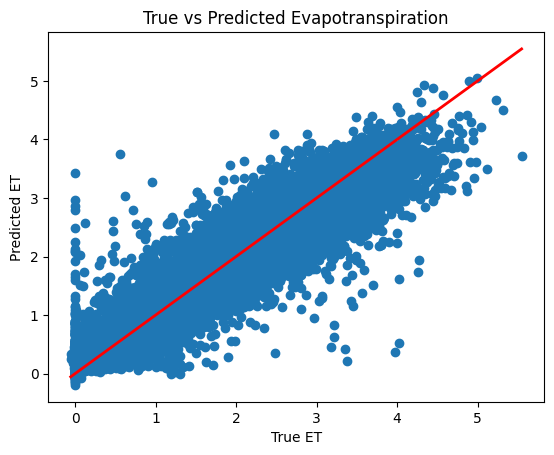

In [172]:
#**  see a plot of the accuracy of the predictions **
plt.scatter(y_test_rescaled, y_pred_rescaled)
plt.plot([min(y_test_rescaled), max(y_test_rescaled)], [min(y_test_rescaled), max(y_test_rescaled)], color='red', lw=2)  # Identity line
plt.xlabel('True ET')
plt.ylabel('Predicted ET')
plt.title('True vs Predicted Evapotranspiration')
plt.show()

**LSTM:**
- sequence lenght = 30
- removed precipitation, mean and max temperature, and max humidity
- loss = MSE
- optimizer = Adam
- batch size = 64

In [237]:
#** build sequences **

unique_locations = reduced_dataset[['longitude', 'latitude']].drop_duplicates()

X_sequences = []
y_sequences = []

sequence_length = 7

feature_cols = ['day_of_year', 'tasmin', 'rhmin', 'ws10', 'ssrd']

for _, loc in unique_locations.iterrows():
    loc_data = reduced_dataset[
        (reduced_dataset['longitude'] == loc['longitude']) &
        (reduced_dataset['latitude'] == loc['latitude'])
    ].sort_values(by='elapsed_days')

    features = loc_data[feature_cols].values
    target = loc_data['E'].values
        
    for i in range(len(loc_data) - sequence_length):
        X_seq = features[i:i+sequence_length]
        y_val = target[i+sequence_length]
        X_sequences.append(X_seq)
        y_sequences.append(y_val)

X = np.array(X_sequences)
y = np.array(y_sequences)

In [238]:
#** build a dataset of shape (n_samples, n_features) **

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape: (158253, 7, 5)
Target vector shape: (158253,)
[[-1.72731039 -0.54994445 -0.61236415  0.45521527 -0.89877809]
 [-1.7178249  -0.63083029 -1.72965944  0.79929114 -1.00886086]
 [-1.70833941 -0.6921534  -0.46973829  1.13055208 -1.09665953]
 [-1.69885391 -0.46786866  0.26167523  0.31736992 -0.98539604]
 [-1.68936842 -0.42187549  0.42714605  0.03509487 -1.05262944]]
-0.064509444


In [239]:
#** mix the sequences of data **
X, y = shuffle(X, y, random_state=42)

print(f"Feature matrix shape after shuffle: {X.shape}")
print(f"Target vector shape after shuffle: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape after shuffle: (158253, 7, 5)
Target vector shape after shuffle: (158253,)
[[-1.23406474 -0.16587355 -1.84848558  0.59680285 -0.21013101]
 [-1.22457925 -0.21550456 -0.99519484  2.27290812 -0.45658922]
 [-1.21509376 -0.67232547 -0.97088301 -0.01445591 -0.11614276]
 [-1.20560827 -0.71285169 -1.46676816 -0.30524967 -0.07416634]
 [-1.19612277 -0.40608318 -1.36934395 -0.13544472 -0.06637421]]
-0.29036474


In [240]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (126602, 7, 5), (126602,)
Testing set shape: (31651, 7, 5), (31651,)


In [242]:
# load the model
loaded_model = tf.keras.models.load_model('./TrainedModels/et_prediction_model_featureSel_06_no_ppn_7days.h5', compile=False)
loaded_model.compile(optimizer='adam', loss='mse')

In [243]:
#** test the model on the test set **
y_pred = loaded_model.predict(X_test)

# invert the normalization of the predicted values
y_pred_rescaled = targetScaler.inverse_transform(y_pred)
y_test_rescaled = targetScaler.inverse_transform(y_test.reshape(-1, 1))

990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [244]:
# R2 score
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
# MAE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print(f"R2 score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 score: 0.8496
RMSE: 0.4238
MAE: 0.2815


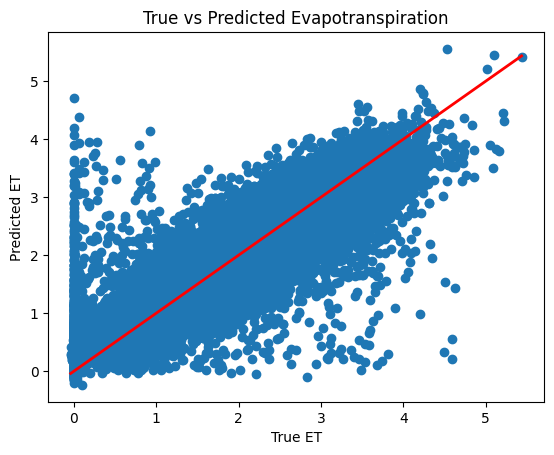

In [245]:
#**  see a plot of the accuracy of the predictions **
plt.scatter(y_test_rescaled, y_pred_rescaled)
plt.plot([min(y_test_rescaled), max(y_test_rescaled)], [min(y_test_rescaled), max(y_test_rescaled)], color='red', lw=2)  # Identity line
plt.xlabel('True ET')
plt.ylabel('Predicted ET')
plt.title('True vs Predicted Evapotranspiration')
plt.show()

**LSTM:**
- sequence lenght = 14
- correlation removal = remove features with correlation > +-0.6
- loss = MSE
- optimizer = Adam
- batch size = 64

In [217]:
#** build sequences **

unique_locations = reduced_dataset[['longitude', 'latitude']].drop_duplicates()

X_sequences = []
y_sequences = []

sequence_length = 14

feature_cols = ['day_of_year', 'tasmin', 'rhmin', 'ws10', 'ssrd', 'ppn']

for _, loc in unique_locations.iterrows():
    loc_data = reduced_dataset[
        (reduced_dataset['longitude'] == loc['longitude']) &
        (reduced_dataset['latitude'] == loc['latitude'])
    ].sort_values(by='elapsed_days')

    features = loc_data[feature_cols].values
    target = loc_data['E'].values
        
    for i in range(len(loc_data) - sequence_length):
        X_seq = features[i:i+sequence_length]
        y_val = target[i+sequence_length]
        X_sequences.append(X_seq)
        y_sequences.append(y_val)

X = np.array(X_sequences)
y = np.array(y_sequences)

In [218]:
#** build a dataset of shape (n_samples, n_features) **

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape: (157644, 14, 6)
Target vector shape: (157644,)
[[-1.72731039 -0.54994445 -0.61236415  0.45521527 -0.89877809 -0.34794209]
 [-1.7178249  -0.63083029 -1.72965944  0.79929114 -1.00886086 -0.45017627]
 [-1.70833941 -0.6921534  -0.46973829  1.13055208 -1.09665953 -0.3851434 ]
 [-1.69885391 -0.46786866  0.26167523  0.31736992 -0.98539604 -0.27086305]
 [-1.68936842 -0.42187549  0.42714605  0.03509487 -1.05262944 -0.41232887]]
-0.94523376


In [219]:
#** mix the sequences of data **
X, y = shuffle(X, y, random_state=42)

print(f"Feature matrix shape after shuffle: {X.shape}")
print(f"Target vector shape after shuffle: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape after shuffle: (157644, 14, 6)
Target vector shape after shuffle: (157644,)
[[ 1.00451165  0.85524778  0.20008508 -0.57903672 -0.92349054 -0.44880917]
 [ 1.01399715  0.62073963  0.00434157 -0.33338606 -0.62368083 -0.45076675]
 [ 1.02348264  0.59333346 -0.34237572 -0.44497723 -0.33184898 -0.45139479]
 [ 1.03296813  0.55695507 -0.46348178 -0.22110176 -0.28085986 -0.45146868]
 [ 1.04245363  0.6077862   0.13992048 -0.23839431 -1.15261974 -0.36531648]]
-0.38762832


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (126115, 14, 6), (126115,)
Testing set shape: (31529, 14, 6), (31529,)


In [ ]:
# import tensorflow as tf

# print(tf.config.list_physical_devices('GPU'))

# # the model learns to predict the next day ET value based on the previous 30 days of data

# model = tf.keras.Sequential()

# model.add(tf.keras.layers.Input(shape=(sequence_length, 6)))  # input shape (sequence_length, n_features)
# model.add(tf.keras.layers.LSTM(128, return_sequences=True))   # return_sequences=True, each of the LSTM cells returns its sequence of 128 outputs. So the output shape is (batch_size, sequence_length, 128)

# model.add(tf.keras.layers.LSTM(64, return_sequences=False)) # return_sequences=False, the last LSTM cell returns its last output. So the output shape is (batch_size, 64)
# model.add(tf.keras.layers.Dropout(0.1))

# model.add(tf.keras.layers.Dense(64, activation='relu'))

# model.add(tf.keras.layers.Dense(1))  # predict a single ET value

# huber_loss = tf.keras.losses.Huber(delta=1.0)

# model.compile(optimizer='adam', loss=huber_loss)
# model.summary()

In [ ]:
# import time

# start_time = time.time()

# history = model.fit(
#     X_train, y_train,
#     batch_size=64,
#     validation_split=0.2,
#     epochs=50,
# )

# end_time = time.time()
# print(f"Training time: {end_time - start_time:.2f} seconds")

In [ ]:
# load the model
loaded_model = tf.keras.models.load_model('./TrainedModels/et_prediction_model_featureSel_06_14days.h5', compile=False)
loaded_model.compile(optimizer='adam', loss='mse')

In [ ]:
#** test the model on the test set **
y_pred = loaded_model.predict(X_test)

# invert the normalization of the predicted values
y_pred_rescaled = targetScaler.inverse_transform(y_pred)
y_test_rescaled = targetScaler.inverse_transform(y_test.reshape(-1, 1))

986/986 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
# R2 score
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
# MAE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print(f"R2 score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 score: 0.9140
RMSE: 0.3213
MAE: 0.2285


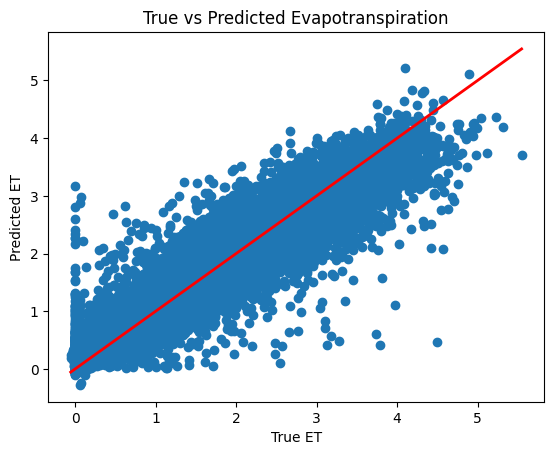

In [ ]:
#**  see a plot of the accuracy of the predictions **
plt.scatter(y_test_rescaled, y_pred_rescaled)
plt.plot([min(y_test_rescaled), max(y_test_rescaled)], [min(y_test_rescaled), max(y_test_rescaled)], color='red', lw=2)  # Identity line
plt.xlabel('True ET')
plt.ylabel('Predicted ET')
plt.title('True vs Predicted Evapotranspiration')
plt.show()

**LSTM:**
- sequence lenght = 30
- random missing input features
- loss = MSE
- optimizer = Adam
- batch size = 64

In [132]:
#** build sequences **

unique_locations = X_pca_df_missing[['longitude', 'latitude']].drop_duplicates()

X_sequences = []
y_sequences = []

sequence_length = 30

feature_cols = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']

for _, loc in unique_locations.iterrows():
    loc_data = X_pca_df_missing[
        (X_pca_df_missing['longitude'] == loc['longitude']) &
        (X_pca_df_missing['latitude'] == loc['latitude'])
    ].sort_values(by='elapsed_days')

    features = loc_data[feature_cols].values
    target = loc_data['E'].values
        
    for i in range(len(loc_data) - sequence_length):
        X_seq = features[i:i+sequence_length]
        y_val = target[i+sequence_length]
        X_sequences.append(X_seq)
        y_sequences.append(y_val)

X = np.array(X_sequences)
y = np.array(y_sequences)

In [133]:
#** build a dataset of shape (n_samples, n_features) **

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape: (156252, 30, 7)
Target vector shape: (156252,)
[[-0.47747851 -1.23599062  0.35673637 -1.2656933  -0.16017416 -0.27141358
  -0.55730479]
 [ 0.14643975 -2.61479294  1.38143059 -0.47259196  0.64451887 -0.30483101
  -0.47577628]
 [-0.92402161 -1.72452852  0.65835422 -0.43866609  0.27523799 -1.40252425
  -0.29710105]
 [-0.96714964 -0.64499681  0.74693026 -0.84474096 -0.52142361 -1.19395562
  -0.3088921 ]
 [-1.11191467 -0.25867368  0.44833347 -1.16090091 -0.58516894 -0.93855539
  -0.94089043]]
-0.85567915


In [134]:
#** mix the sequences of data **
from sklearn.utils import shuffle

X, y = shuffle(X, y, random_state=42)

print(f"Feature matrix shape after shuffle: {X.shape}")
print(f"Target vector shape after shuffle: {y.shape}")
print(X[0][:5])
print(y[0])

Feature matrix shape after shuffle: (156252, 30, 7)
Target vector shape after shuffle: (156252,)
[[ 1.80508098  1.95914356  1.40960337  0.32789588 -1.341699   -0.65188695
   0.76890928]
 [ 2.55765627  0.83987956  0.51774133 -0.17288506 -0.91891586 -0.00640899
   0.10746172]
 [ 2.74784787  0.79548854 -0.12848133  0.02598887 -0.08204084 -0.500481
   0.90327473]
 [ 3.18050795  0.56030625  0.63516645  0.26177637 -0.43979308 -0.09511541
   0.59639782]
 [ 2.56166962  0.65790576  0.08197728  0.54425731  0.31883368 -1.2875104
   0.49808482]]
-1.1966311


In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (125001, 30, 7), (125001,)
Testing set shape: (31251, 30, 7), (31251,)


In [136]:
# load the model
loaded_model = tf.keras.models.load_model('./TrainedModels/et_prediction_model_nanValues.h5', compile=False)
loaded_model.compile(optimizer='adam', loss='mse')

In [ ]:
#** test the model on the test set **
y_pred = loaded_model.predict(X_test)


# invert the normalization of the predicted values
y_pred_rescaled = targetScaler.inverse_transform(y_pred)
y_test_rescaled = targetScaler.inverse_transform(y_test.reshape(-1, 1))

977/977 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


In [138]:
# R2 score
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
# RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
# MAE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print(f"R2 score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 score: 0.8885
RMSE: 0.3652
MAE: 0.2566


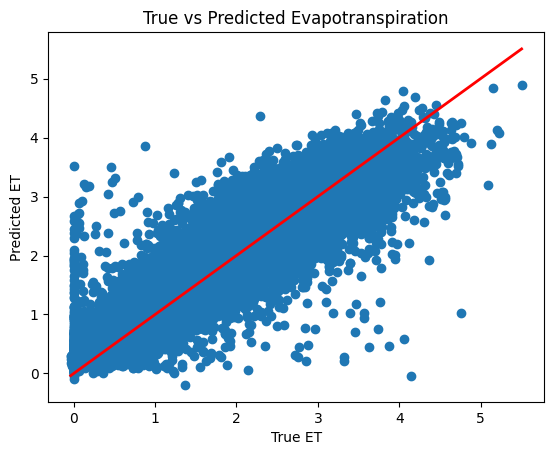

In [139]:
#**  see a plot of the accuracy of the predictions **
plt.scatter(y_test_rescaled, y_pred_rescaled)
plt.plot([min(y_test_rescaled), max(y_test_rescaled)], [min(y_test_rescaled), max(y_test_rescaled)], color='red', lw=2)  # Identity line
plt.xlabel('True ET')
plt.ylabel('Predicted ET')
plt.title('True vs Predicted Evapotranspiration')
plt.show()